In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
#load data
matches = pd.read_csv("data/matches.csv")
deliveries = pd.read_csv("data/deliveries.csv")

In [15]:
#clean data
matches = matches.dropna(subset=['winner'])

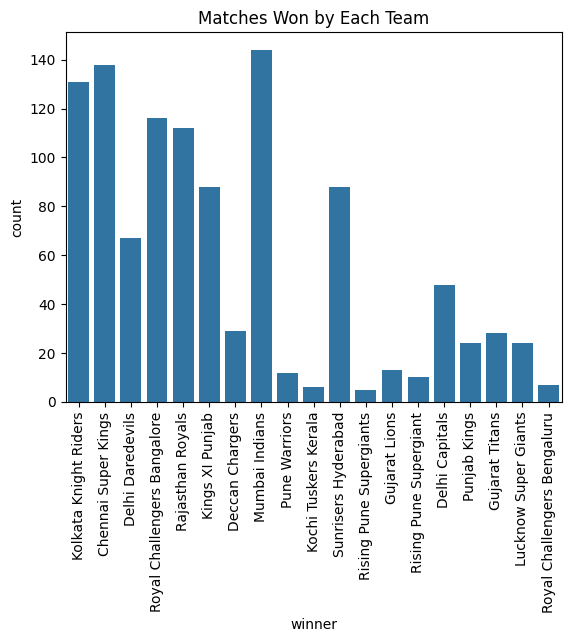

In [16]:
#matches won
sns.countplot(x='winner', data=matches)
plt.xticks(rotation=90)
plt.title("Matches Won by Each Team")
plt.show()

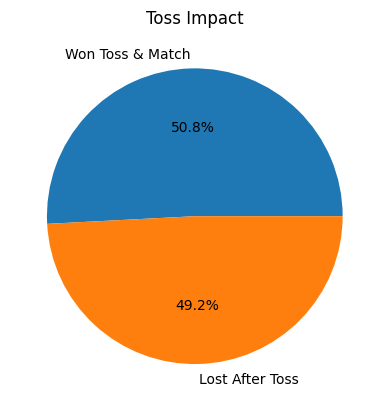

In [17]:
#toss impact
toss_win = matches[matches['toss_winner'] == matches['winner']]

labels = ['Won Toss & Match', 'Lost After Toss']
sizes = [len(toss_win), len(matches) - len(toss_win)]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Toss Impact")
plt.show()

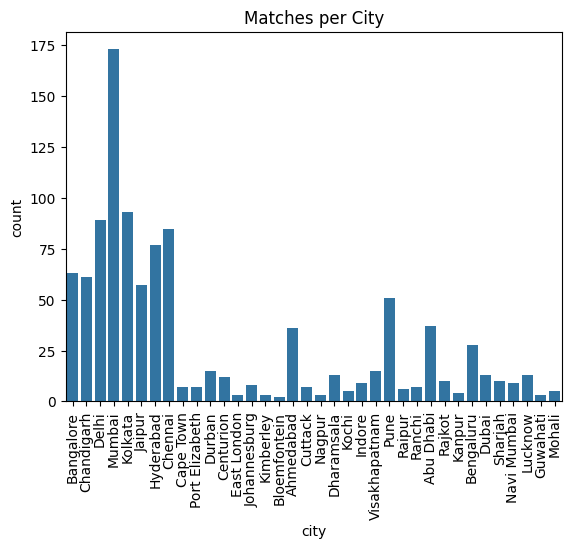

In [18]:
#matches per city
sns.countplot(x='city', data=matches)
plt.xticks(rotation=90)
plt.title("Matches per City")
plt.show()

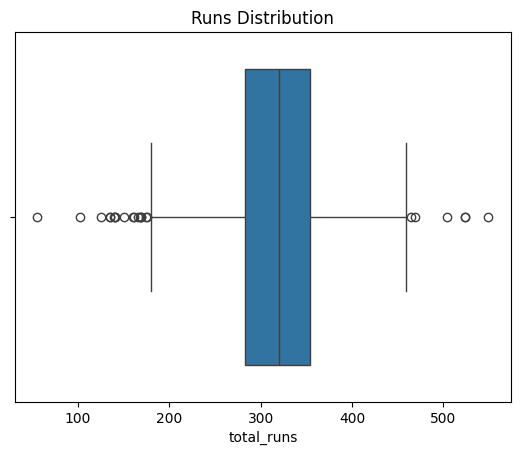

In [19]:
#box plot
total_runs = deliveries.groupby('match_id')['total_runs'].sum()

sns.boxplot(x=total_runs)
plt.title("Runs Distribution")
plt.show()

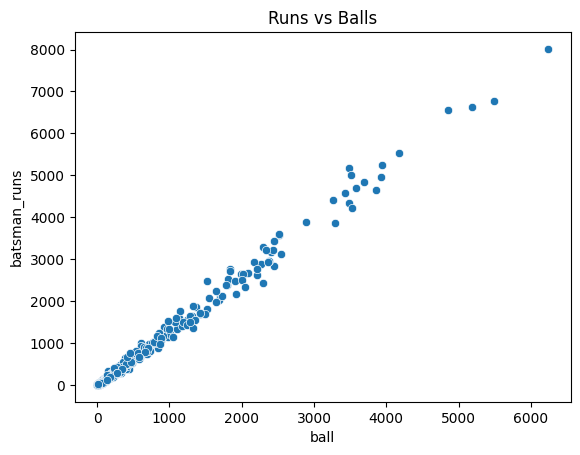

In [20]:
#scatter plot
player_stats = deliveries.groupby('batter').agg({
    'batsman_runs':'sum',
    'ball':'count'
})

sns.scatterplot(x='ball', y='batsman_runs', data=player_stats)
plt.title("Runs vs Balls")
plt.show()

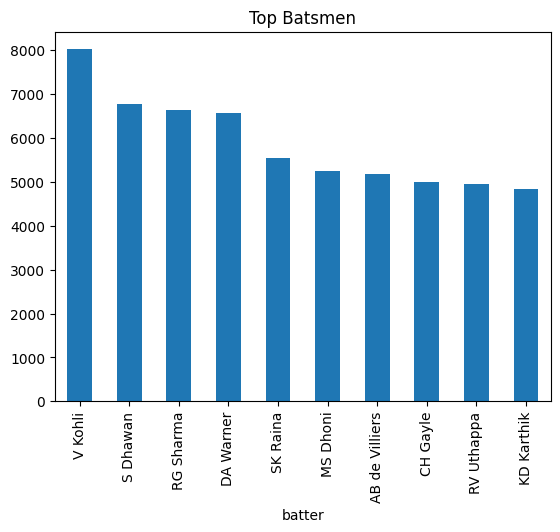

In [21]:
#top batsman
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

top_batsmen.plot(kind='bar')
plt.title("Top Batsmen")
plt.show()

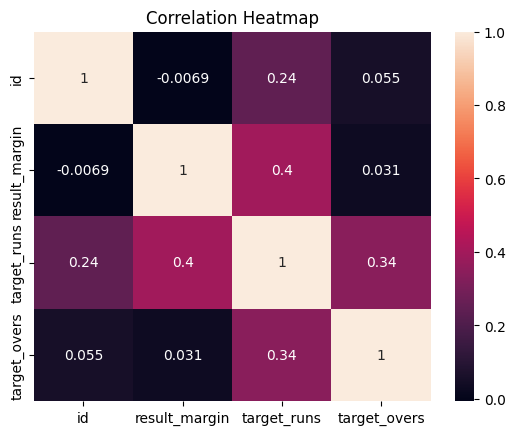

In [22]:
#heatmap
corr = matches.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

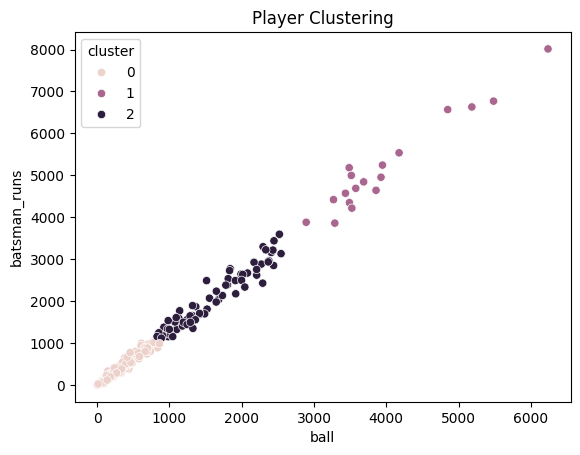

In [23]:
#clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
player_stats['cluster'] = kmeans.fit_predict(player_stats)

sns.scatterplot(x='ball', y='batsman_runs', hue='cluster', data=player_stats)
plt.title("Player Clustering")
plt.show()

In [24]:
#winner prediction
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

data = matches[['team1','team2','toss_winner','winner']].dropna()

le = LabelEncoder()

for col in data.columns:
    data[col] = le.fit_transform(data[col])

X = data[['team1','team2','toss_winner']]
y = data['winner']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,y_train)

print("Accuracy:", model.score(X_test,y_test))

Accuracy: 0.5229357798165137
